In [7]:
from pathlib import Path

models_dir = Path(r"F:/01_Univalle/01_TG/nuevo_dataset")
anisognathus = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/anisognathus_somptuosus")
chlorophanes = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/chlorophanes_spiza")
delphinae = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/colibri_delphinae")
florisuga = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/florisuga_mellivora")
myioborus = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/myioborus_miniatus")
ocreatus = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/ocreatus_underwoodii")
ramphocelus = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/ramphocelus_flamigerus")
setophaga = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/setophaga_fusca")
stilpnia = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/stilpnia_vitriolina")
arthus = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/tangara_arthus")
turdus = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/turdus_ignobilis")
zonotrichia = Path(r"F:/01_Univalle/01_TG/nuevo_dataset/zonotrichia_capensis")

import cv2
import numpy as np
import torch
from typing import List, Dict, Tuple
from PIL import Image

from bird_detector import preprocess_image_for_detector, run_detector_on_image, load_detector

def get_bird_crops(pil_img: Image.Image, conf_threshold: float = 0.7, margin: int = 10) -> List[Dict]:
    """
    Run the detector on a PIL image and return a list of bird crops.

    Each element of the list is a dict:
        {
            "crop_bgr": np.ndarray  # bird patch in BGR (for cv2),
            "box": [x1, y1, x2, y2],
            "score": float
        }

    margin: extra pixels added around the bbox (clipped to image borders).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, coco_classes = load_detector(device)
    # --- 1) detector input tensor ---
    img_tensor = preprocess_image_for_detector(pil_img, device)

    # --- 2) run detector (you already have this function) ---
    detections = run_detector_on_image(
        model,
        coco_classes,
        img_tensor,
        target_class="bird",
        conf_threshold=conf_threshold
    )

    # --- 3) original image as numpy (RGB) then BGR for cv2 ---
    img_rgb = np.array(pil_img)              # H,W,3 (RGB)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    h, w = img_bgr.shape[:2]

    bird_crops = []
    for det in detections:
        x1, y1, x2, y2 = det["box"]
        # add margin
        x1 = max(0, int(x1) - margin)
        y1 = max(0, int(y1) - margin)
        x2 = min(w, int(x2) + margin)
        y2 = min(h, int(y2) + margin)

        crop = img_bgr[y1:y2, x1:x2].copy()
        if crop.size == 0:
            continue

        bird_crops.append({
            "crop_bgr": crop,
            "box": [x1, y1, x2, y2],
            "score": det["score"]
        })

    return bird_crops


def detect_main_bird_crop(pil_img: Image.Image, model, coco_classes, device, conf_threshold: float = 0.7, margin: int = 10) -> Tuple[np.ndarray, Dict]:
    """
    Convenience wrapper:
    Returns (crop_bgr, info_dict) for the *best* bird detection
    (highest score), or (None, {}) if no bird is detected.
    """
    crops = get_bird_crops(
        pil_img,
        model,
        coco_classes,
        device,
        conf_threshold=conf_threshold,
        margin=margin
    )
    if not crops:
        return None, {}

    # choose highest-score detection
    best = max(crops, key=lambda d: d["score"])
    return best["crop_bgr"], best


def otsu_segmentation(img: np.ndarray, blur_ksize: int = 5, morph_kernel_size: int = 5, morph_iterations: int = 1):
    """
    Apply Otsu thresholding to segment foreground (bird) from background.

    Parameters
    ----------
    img : np.ndarray
        Input color image as a NumPy array (H x W x 3).
        Assumed BGR if loaded with cv2.imread.
    blur_ksize : int, optional
        Size of the Gaussian blur kernel (must be odd).
        A small blur helps reduce noise before thresholding.
    morph_kernel_size : int, optional
        Size of the square kernel used for morphological operations.
    morph_iterations : int, optional
        Number of iterations for morphological open/close to clean the mask.

    Returns
    -------
    mask : np.ndarray
        Binary mask (H x W) with values 0 (background) or 255 (foreground).
    segmented : np.ndarray
        Color image where background is set to black and foreground is kept.

    What it does
    ------------
    1. Converts the image to grayscale.
    2. Applies a small Gaussian blur to reduce noise.
    3. Applies Otsu's automatic threshold to separate foreground/background.
    4. Cleans the mask with morphological operations (open + close).
    5. Applies the mask to the original image to obtain the segmented result.
    """
    # 1) Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2) Gaussian blur (helps Otsu in noisy images)
    if blur_ksize % 2 == 0:
        blur_ksize += 1  # kernel size must be odd
    gray_blur = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)

    # 3) Otsu thresholding -> mask with 0 or 255
    _, mask = cv2.threshold(
        gray_blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 4) Morphological operations to clean small noise
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=morph_iterations)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=morph_iterations)

    # 5) Apply mask to original image
    segmented = cv2.bitwise_and(img, img, mask=mask)

    return mask, segmented


def grabcut_segmentation(img: np.ndarray, n_iter: int = 15, margin: int = 10):
    """
    Apply GrabCut automatically using the whole image as initial foreground.

    Parameters
    ----------
    img : np.ndarray
        Input color image as a NumPy array (H x W x 3), BGR (cv2).
    n_iter : int, optional
        Number of GrabCut iterations. More iterations -> better, but slower.
    margin : int, optional
        Margin in pixels around the image that is considered probable background.
        Inside this margin is more likely foreground.

    Returns
    -------
    mask : np.ndarray
        Binary mask (H x W) with values 0 (background) or 255 (foreground).
    segmented : np.ndarray
        Color image where background is set to black and foreground is kept.

    What it does
    ------------
    1. Creates a rectangle slightly smaller than the full image (crop the borders).
    2. Initializes GrabCut with this rectangle:
       - inside rectangle = probable foreground
       - outside rectangle = probable background
    3. Runs GrabCut for 'n_iter' iterations.
    4. Converts GrabCut labels to a binary mask (foreground vs background).
    5. Applies the mask to the original image to obtain the segmented result.

    This version does NOT require any manual drawing of masks.
    """
    h, w = img.shape[:2]

    # Rectangle inside the image borders (to mark likely foreground)
    x = margin
    y = margin
    rect_w = max(1, w - 2 * margin)
    rect_h = max(1, h - 2 * margin)
    rect = (x, y, rect_w, rect_h)

    # Initialize mask and models required by GrabCut
    grabcut_mask = np.zeros((h, w), np.uint8)
    bg_model = np.zeros((1, 65), np.float64)  # background model
    fg_model = np.zeros((1, 65), np.float64)  # foreground model

    # Run GrabCut
    cv2.grabCut(
        img,
        grabcut_mask,
        rect,
        bg_model,
        fg_model,
        n_iter,
        cv2.GC_INIT_WITH_RECT
    )

    # Convert GrabCut result to binary mask:
    # 0,2 -> background; 1,3 -> foreground
    mask = np.where(
        (grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD),
        255,
        0
    ).astype("uint8")

    # Apply mask
    segmented = cv2.bitwise_and(img, img, mask=mask)

    return mask, segmented


def hsv_segmentation(img: np.ndarray, h_min: int = 0, h_max: int = 179, s_min: int = 0, s_max: int = 255, v_min: int = 0, v_max: int = 255, morph_kernel_size: int = 3, morph_iterations: int = 1):
    """
    Segment foreground using color in HSV space.

    Parameters
    ----------
    img : np.ndarray
        Input color image (H x W x 3), BGR as loaded by cv2.imread.
    h_min, h_max : int
        Lower and upper bounds for Hue   (0–179 in OpenCV).
    s_min, s_max : int
        Lower and upper bounds for Saturation (0–255).
    v_min, v_max : int
        Lower and upper bounds for Value/brightness (0–255).
    morph_kernel_size : int
        Size of the square kernel for morphological cleaning.
    morph_iterations : int
        Number of open/close iterations.

    Returns
    -------
    mask : np.ndarray
        Binary mask (0 background, 255 foreground).
    segmented : np.ndarray
        Image with background removed (black) and foreground kept.

    What it does
    ------------
    1. Converts BGR → HSV.
    2. Keeps pixels whose H, S, V lie in the given ranges.
    3. Cleans the mask with morphological operations.
    4. Applies the mask to the original image.
    """
    # 1) BGR → HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 2) Build lower/upper bounds
    lower = np.array([h_min, s_min, v_min], dtype=np.uint8)
    upper = np.array([h_max, s_max, v_max], dtype=np.uint8)

    # 3) Threshold in HSV space
    mask = cv2.inRange(hsv, lower, upper)

    # 4) Morphological cleaning
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=morph_iterations)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=morph_iterations)

    # 5) Apply mask
    segmented = cv2.bitwise_and(img, img, mask=mask)

    return mask, segmented


def saliency_grabcut_segmentation(img: np.ndarray, saliency_thresh: float = 0.5, n_iter: int = 5, morph_kernel_size: int = 3, morph_iterations: int = 1):
    """
    Segment the main salient object using:
      1) Classical saliency (Spectral Residual, no deep learning),
      2) GrabCut initialized with the saliency mask.

    Parameters
    ----------
    img : np.ndarray
        Input BGR image (H x W x 3).
    saliency_thresh : float
        Threshold in [0,1] applied to the saliency map
        (higher -> smaller, more confident foreground).
    n_iter : int
        Number of GrabCut iterations.
    morph_kernel_size : int
        Kernel size for morphological cleaning.
    morph_iterations : int
        Number of open/close iterations.

    Returns
    -------
    mask : np.ndarray
        Binary mask (0 background, 255 foreground).
    segmented : np.ndarray
        Image with background removed (black).
    """

    h, w = img.shape[:2]

    # 1) Compute saliency map (classical method)
    saliency = cv2.saliency.StaticSaliencySpectralResidual.create()
    success, sal_map = saliency.computeSaliency(img)
    if not success:
        raise RuntimeError("Saliency computation failed.")

    # sal_map is float32 in [0,1]
    sal_map_uint8 = (sal_map * 255).astype("uint8")

    # 2) Threshold saliency to get a rough foreground mask
    _, sal_mask = cv2.threshold(
        sal_map_uint8,
        int(saliency_thresh * 255),
        255,
        cv2.THRESH_BINARY
    )

    # 3) Prepare GrabCut mask using saliency:
    #    high saliency -> probable foreground, low -> probable background
    grabcut_mask = np.where(
        sal_mask == 255,
        cv2.GC_PR_FGD,
        cv2.GC_PR_BGD
    ).astype("uint8")

    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)

    # 4) Run GrabCut with mask initialization
    cv2.grabCut(
        img,
        grabcut_mask,
        None,          # no rectangle, we use the mask
        bg_model,
        fg_model,
        n_iter,
        cv2.GC_INIT_WITH_MASK
    )

    # 5) Convert GrabCut labels to binary mask
    mask = np.where(
        (grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD),
        255,
        0
    ).astype("uint8")

    # 6) Optional morphological cleaning
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=morph_iterations)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=morph_iterations)

    # 7) Apply mask
    segmented = cv2.bitwise_and(img, img, mask=mask)

    return mask, segmented



0


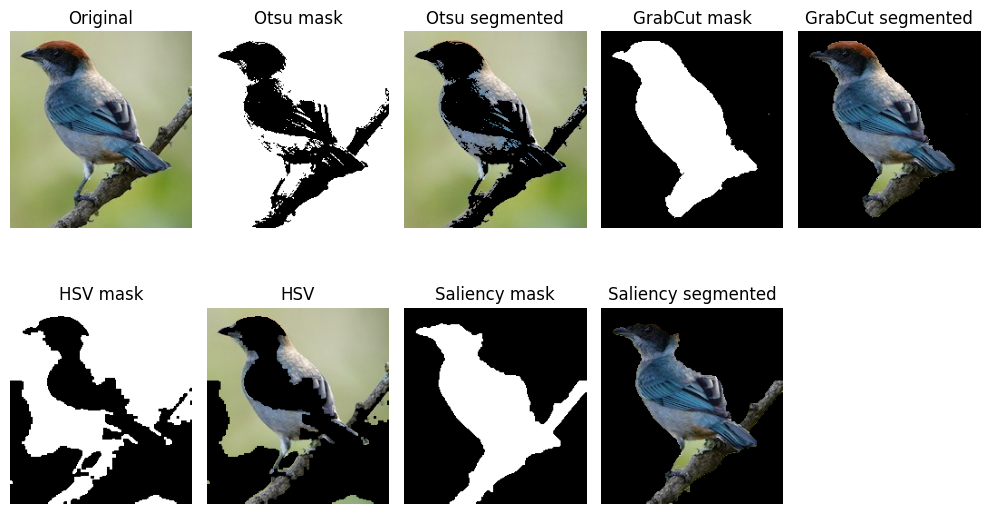

In [49]:
import matplotlib.pyplot as plt
# Suppose img is your bird crop loaded with cv2 (BGR)
# img_path = turdus/"ML639423991.jpeg"
# img_path = turdus/"ML639003056.jpeg"
# img_path = ocreatus/"ML641698822.jpg"
# img_path = anisognathus/"ML637552213.jpg"
# img_path = setophaga/"ML641977976.jpg"
img_path = stilpnia/"ML639273473.jpg"
# print(img_path)
# print(img_path.exists())


img = Image.open(img_path).convert("RGB")
# img.show()
cropped_image = get_bird_crops(img)
# img = cv2.imread(str(img_path))
# print(img)

for i, det in enumerate(cropped_image):
    print(i)
    pil_img = det["crop_bgr"]
    mask_otsu, seg_otsu = otsu_segmentation(pil_img, blur_ksize = 1, morph_kernel_size = 1, morph_iterations = 7)
    mask_gc,   seg_gc   = grabcut_segmentation(pil_img, n_iter=3, margin=10)
    mask_hsv, seg_hsv   = hsv_segmentation(pil_img, h_min = 0, h_max = 179, s_min = 0, s_max= 80, v_min= 40, v_max = 255, morph_kernel_size = 3, morph_iterations = 1)
    mask_sal_gc, seg_sal_gc = saliency_grabcut_segmentation(pil_img, saliency_thresh=0.2, n_iter = 5, morph_kernel_size = 3, morph_iterations = 1)

    # Show results (remember to convert BGR -> RGB for matplotlib)
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 5, 1); plt.title("Original"); plt.imshow(cv2.cvtColor(pil_img, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.subplot(2, 5, 2); plt.title("Otsu mask"); plt.imshow(mask_otsu, cmap="gray"); plt.axis("off")
    plt.subplot(2, 5, 3); plt.title("Otsu segmented"); plt.imshow(cv2.cvtColor(seg_otsu, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.subplot(2, 5, 4); plt.title("GrabCut mask"); plt.imshow(mask_gc, cmap="gray"); plt.axis("off")
    plt.subplot(2, 5, 5); plt.title("GrabCut segmented"); plt.imshow(cv2.cvtColor(seg_gc, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.subplot(2, 5, 6); plt.title("HSV mask"); plt.imshow(mask_hsv, cmap="gray"); plt.axis("off")
    plt.subplot(2, 5, 7); plt.title("HSV"); plt.imshow(cv2.cvtColor(seg_hsv, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.subplot(2, 5, 8); plt.title("Saliency mask"); plt.imshow(mask_sal_gc, cmap="gray"); plt.axis("off")
    plt.subplot(2, 5, 9); plt.title("Saliency segmented"); plt.imshow(cv2.cvtColor(seg_sal_gc, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.tight_layout()
    plt.show()


In [1]:
# import sys
# print(sys.executable)
import numpy as np
import cv2

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("has saliency:", "saliency" in dir(cv2))


NumPy: 1.26.4
OpenCV: 4.7.0
has saliency: True
